# Hotazel Steam: Forecasting Model Comparison
# Made by Haaris Mian
## small description here
## link to my resume on a google drive link


## Step 1: Load libraries and the data
Import pandas, numpy, and matplotlib for data handling and plotting, and statsmodels for the actual regression. The float_format line just turns off scientific notation so revenue reads as normal numbers.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# turn off scientific notation
pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')
HS_data.info()
display(HS_data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   type        48 non-null     object
 1   date        48 non-null     object
 2   revenue     48 non-null     int64 
 3   production  48 non-null     int64 
 4   coolDD      48 non-null     int64 
 5   heatDD      48 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.4+ KB


,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223




## Step 2: Fix the date type and look at revenue over time
The date column shows as text, but is converted to a real datetime. Then revenue is plotted over time to see the shape of what is being predicted. There is a seasonal pattern of winter peaks.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   type        48 non-null     object        
 1   date        48 non-null     datetime64[ns]
 2   revenue     48 non-null     int64         
 3   production  48 non-null     int64         
 4   coolDD      48 non-null     int64         
 5   heatDD      48 non-null     int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 2.4+ KB


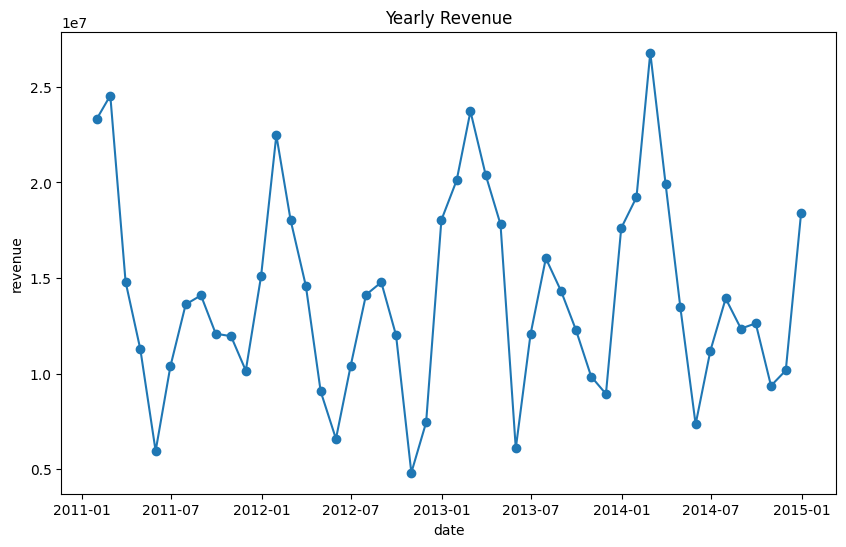

In [ ]:
HS_data['date'] = pd.to_datetime(HS_data['date'])
HS_data.info()

plt.figure(figsize=(10,6))
plt.title('Yearly Revenue')
plt.xlabel('date')
plt.ylabel('revenue')
plt.plot(HS_data['date'], HS_data['revenue'], marker='o')
plt.show()

## Step 3: Check to see for any correlations
.corr() function gives a relationship between the revenue and each feature. Before modelling, we can see which features are likely to be important and useful predictors.  

Values close to +1 or -1 are strong and values near 0 are weak. We expect production and heatDD to both show a positive relationship with revenue.

In [ ]:
HS_data.loc[:, ['revenue','production','coolDD','heatDD']].corr()

,revenue,production,coolDD,heatDD
revenue,1.00,0.63,-0.17,0.69
production,0.63,1.00,0.51,0.03
coolDD,-0.17,0.51,1.00,-0.72
heatDD,0.69,0.03,-0.72,1.00


Therefore, both production (≈0.63) and heatDD (≈0.69) correlate positively with revenue, and heatDD is slightly stronger. coolDD is weak or negative, which is why neither of the models uses it.

## Step 4: Split into training and testing
We use the type column to separate the data. THe model learns from training data and testing data is held back so we can judge the forecast accuracy on unseen months fairly.

In [ ]:
dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing  = HS_data.loc[HS_data['type']=='dt4testing']

print('Training rows:', len(dt4training), '| Testing rows:', len(dt4testing))
display(dt4training)
display(dt4testing)

Training rows: 36 | Testing rows: 12


,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


,type,date,revenue,production,coolDD,heatDD
36,dt4testing,2014-01-31,19228840,606400,0,1123
37,dt4testing,2014-02-28,26792280,714128,0,938
38,dt4testing,2014-03-31,19935840,805600,0,866
39,dt4testing,2014-04-30,13468000,375856,0,412
40,dt4testing,2014-05-31,7344128,279296,49,88
41,dt4testing,2014-06-30,11196216,517600,230,0
42,dt4testing,2014-07-31,13929472,749472,380,0
43,dt4testing,2014-08-31,12352176,663432,322,0
44,dt4testing,2014-09-30,12628944,701656,178,14
45,dt4testing,2014-10-31,9361000,411728,24,166



# MODEL 1

### Step 5: Train Model 1
The first model is built and it is told what to predict (revenue) and what to use for predicting (production). We add a constant so the line can start at the right height, then fit the model to the training data. .summary() shows the results and check the R-squared to see how well it fits.

In [ ]:
y = dt4training.loc[:, 'revenue']
x = dt4training.loc[:, 'production']
x = sm.add_constant(x)

model1 = sm.OLS(y, x).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     22.35
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           3.86e-05
Time:                        21:57:53   Log-Likelihood:                -598.32
No. Observations:                  36   AIC:                             1201.
Df Residuals:                      34   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.898e+06   2.01e+06      2.431      0.020    8.03e+05    8.99e+06
production    18.9920      4.017      4.728      0.000      10.828      27.156
==============================================================================
Omnibus:                        5.412   Durbin-Watson:                   0.444
Prob(Omnibus):                  0.067   Jarque-Bera (JB):                2.625
Skew:                           0.392   Prob(JB):                        0.269
Kurtosis:                       1.934   Cond. No.                     1.47e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.47e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Step 6: Model 1 equation
Pulling the fitted parameters gives us the line revenue = slope * production + intercept.

In [ ]:
model1.params
# revenue = model1.params['production'] * production + model1.params['const']

,0
const,4897663.26
production,18.99


### Step 7: Forecast with Model 1 and score MAPE
We take the 2014 testing data and use the model to predict revenue for each month. Then we check how far off each prediction was using MAPE: for each month, how big the miss was as a % of the real revenue, then averaged across all months. A lower MAPE means better predictions. We copy the testing data into a separate frame first so the original stays untouched.

In [ ]:
x_test = dt4testing.loc[:, 'production']
x_test = sm.add_constant(x_test)

model1_assessment = dt4testing.copy()
model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)
model1_assessment['model1_pctError'] = abs(
    (model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue'])
    / model1_assessment['revenue']
)
display(model1_assessment)

model1_mape = model1_assessment['model1_pctError'].mean()
print('Model 1 MAPE:', round(model1_mape*100, 2), '%')

,type,date,revenue,production,coolDD,heatDD,model1_predicted_revenue,model1_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,16414428.69,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,18460401.82,0.31
38,dt4testing,2014-03-31,19935840,805600,0,866,20197640.55,0.01
39,dt4testing,2014-04-30,13468000,375856,0,412,12035930.72,0.11
40,dt4testing,2014-05-31,7344128,279296,49,88,10202060.55,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,14727936.65,0.32
42,dt4testing,2014-07-31,13929472,749472,380,0,19131656.04,0.37
43,dt4testing,2014-08-31,12352176,663432,322,0,17497582.00,0.42
44,dt4testing,2014-09-30,12628944,701656,178,14,18223533.25,0.44
45,dt4testing,2014-10-31,9361000,411728,24,166,12717212.73,0.36


Model 1 MAPE: 25.42 %



# MODEL 2 (Steps for Model 2 are not explained as they are the same as Model 1 steps)


### Step 8: Train Model 2

In [ ]:
y2 = dt4training.loc[:, 'revenue']
x2 = dt4training.loc[:, 'heatDD']
x2 = sm.add_constant(x2)

model2 = sm.OLS(y2, x2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     25.44
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           1.51e-05
Time:                        21:57:53   Log-Likelihood:                -597.36
No. Observations:                  36   AIC:                             1199.
Df Residuals:                      34   BIC:                             1202.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.033e+07   9.66e+05     10.699      0.000    8.37e+06    1.23e+07
heatDD      9991.2575   1980.834      5.044      0.000    5965.719     1.4e+04
==============================================================================
Omnibus:                        2.430   Durbin-Watson:                   1.298
Prob(Omnibus):                  0.297   Jarque-Bera (JB):                2.126
Skew:                          -0.492   Prob(JB):                        0.345
Kurtosis:                       2.330   Cond. No.                         706.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Step 9: Model 2 equation

In [ ]:
model2.params
# revenue = model2.params['heatDD'] * heatDD + model2.params['const']

,0
const,10333861.28
heatDD,9991.26


### Step 10: Forecast with Model 2 and score MAPE

In [ ]:
x2_test = dt4testing.loc[:, 'heatDD']
x2_test = sm.add_constant(x2_test)

model2_assessment = dt4testing.copy()
model2_assessment['model2_predicted_revenue'] = model2.predict(x2_test)
model2_assessment['model2_pctError'] = abs(
    (model2_assessment['revenue'] - model2_assessment['model2_predicted_revenue'])
    / model2_assessment['revenue']
)
display(model2_assessment)

model2_mape = model2_assessment['model2_pctError'].mean()
print('Model 2 MAPE:', round(model2_mape*100, 2), '%')

,type,date,revenue,production,coolDD,heatDD,model2_predicted_revenue,model2_pctError
36,dt4testing,2014-01-31,19228840,606400,0,1123,21554043.42,0.12
37,dt4testing,2014-02-28,26792280,714128,0,938,19705660.79,0.26
38,dt4testing,2014-03-31,19935840,805600,0,866,18986290.25,0.05
39,dt4testing,2014-04-30,13468000,375856,0,412,14450259.35,0.07
40,dt4testing,2014-05-31,7344128,279296,49,88,11213091.93,0.53
41,dt4testing,2014-06-30,11196216,517600,230,0,10333861.28,0.08
42,dt4testing,2014-07-31,13929472,749472,380,0,10333861.28,0.26
43,dt4testing,2014-08-31,12352176,663432,322,0,10333861.28,0.16
44,dt4testing,2014-09-30,12628944,701656,178,14,10473738.88,0.17
45,dt4testing,2014-10-31,9361000,411728,24,166,11992410.02,0.28


Model 2 MAPE: 21.65 %



## Step 11: Visual comparison of both models vs actual
Green shows ghe actual 2014 revenue. Red  shows the Model 1 (production) forecast. Blue shows the Model 2 (heatDD) forecast. The closer a line sticks to green, the better the model tracks reality.

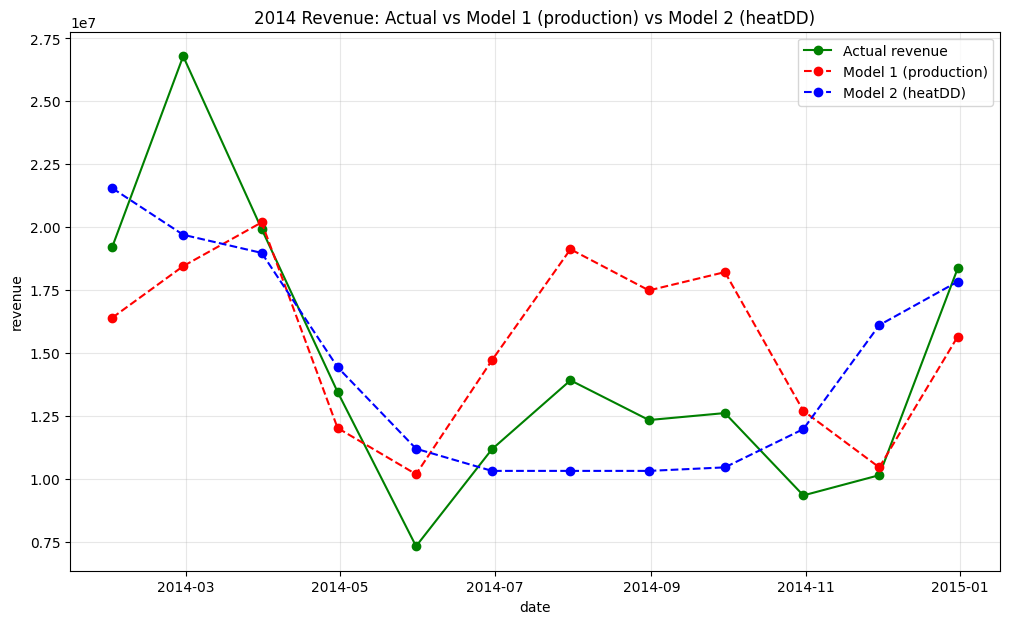

In [ ]:
plt.figure(figsize=(12,7))
plt.title('2014 Revenue: Actual vs Model 1 (production) vs Model 2 (heatDD)')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1_assessment['date'], model1_assessment['revenue'],
         marker='o', color='green', label='Actual revenue')
plt.plot(model1_assessment['date'], model1_assessment['model1_predicted_revenue'],
         marker='o', color='red', linestyle='--', label='Model 1 (production)')
plt.plot(model2_assessment['date'], model2_assessment['model2_predicted_revenue'],
         marker='o', color='blue', linestyle='--', label='Model 2 (heatDD)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Step 12: Side-by-side score summary

In [ ]:
summary = pd.DataFrame({
    'Model': ['Model 1 (production)', 'Model 2 (heatDD)'],
    'R-squared (train)': [round(model1.rsquared, 4), round(model2.rsquared, 4)],
    'MAPE (test) %': [round(model1_mape*100, 2), round(model2_mape*100, 2)]
})
display(summary)

,Model,R-squared (train),MAPE (test) %
0,Model 1 (production),0.40,25.42
1,Model 2 (heatDD),0.43,21.65



## Step 13  Memo: Key Findings

**To:** Hotazel Steam

**Re:** Comparison of two single-variable revenue forecasting models

Two forecasting models have been built and tested for monthly revenue where one is driven by production, and one by heating degree days (heatDD). Both models were trained on 2011–2013 data and tested on the 12 months of 2014 that neither model had seen. The heatDD model (Model 2) is the stronger forecaster as it as a test MAPE of roughly 21.6% vs. roughly 25.4% MAPE for the production model. As a result, Model 2's monthly revenue forecasts were off by about 22% on average, compared to about 25% for Model 1.

As a steam supplier, Hotazel's revenue is seasonal and tied to demand for heat — colder months meaning with more heating degree days equals more revenue. This can be see in the numbers where heatDD correlates with revenue slightly more strongly than production does (around 0.69 vs around 0.63) and produces a marginally better in-sample fit (R² is around 0.43 vs around 0.40). The visualization shows this as well where the heatDD line tracks the winter revenue peaks more closely.

However, even the better model carries ~22% average error, which is high for confident forecasting. Both R² values sit near 0.4, meaning a single variable explains under half of the revenue variation. Neither of the models alone are precise enough to rely on for planning. I would recommend testing a multi-feature model, for example, heatDD and production together as a next steps could reduce errors by a lot.  

Recommendation. Of the two options requested, Model 2 (heatDD) is recommended for use. However, it should be treated as a directional estimate, and a combined model should be built before it is used for any financial commitments.

